In [1]:
print("Bay Area Traffic Analysis")

Bay Area Traffic Analysis


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

Matplotlib is building the font cache; this may take a moment.


Pandas: 3.0.5
Scikit-learn: 1.9.0


In [3]:
with open("../data/raw/i280_nb_stevens_creek_400560_5min.txt", "r") as file:
    for _ in range(10):
        print(file.readline())

5 Minutes	Flow (Veh/5 Minutes)	Speed (mph)	# Lane Points	% Observed

08/03/2026 00:00	30.0	67.2	4	100.0

08/03/2026 00:05	41.0	67.2	4	100.0

08/03/2026 00:10	32.0	67.5	4	100.0

08/03/2026 00:15	37.0	67.1	4	100.0

08/03/2026 00:20	34.0	67.8	4	100.0

08/03/2026 00:25	38.0	66.7	4	100.0

08/03/2026 00:30	33.0	66.7	4	100.0

08/03/2026 00:35	20.0	67.9	4	100.0

08/03/2026 00:40	29.0	68.2	4	100.0



In [4]:
stevens = pd.read_csv(
    "../data/raw/i280_nb_stevens_creek_400560_5min.txt",
    sep=r"\s+",
    skiprows=1,
    names=[
        "date",
        "time",
        "flow",
        "speed",
        "lane_points",
        "observed_pct"
    ]
)

In [5]:
stevens.head()

,date,time,flow,speed,lane_points,observed_pct
0,08/03/2026,00:00,30.0,67.2,4,100.0
1,08/03/2026,00:05,41.0,67.2,4,100.0
2,08/03/2026,00:10,32.0,67.5,4,100.0
3,08/03/2026,00:15,37.0,67.1,4,100.0
4,08/03/2026,00:20,34.0,67.8,4,100.0


In [6]:
stevens.shape

(2016, 6)

In [7]:
stevens.info()

<class 'pandas.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2016 non-null   str    
 1   time          2016 non-null   str    
 2   flow          2016 non-null   float64
 3   speed         2016 non-null   float64
 4   lane_points   2016 non-null   int64  
 5   observed_pct  2016 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 94.6 KB


In [8]:
stevens["timestamp"] = pd.to_datetime(
    stevens["date"] + " " + stevens["time"]
)

In [9]:
stevens.head()

,date,time,flow,speed,lane_points,observed_pct,timestamp
0,08/03/2026,00:00,30.0,67.2,4,100.0,2026-08-03 00:00:00
1,08/03/2026,00:05,41.0,67.2,4,100.0,2026-08-03 00:05:00
2,08/03/2026,00:10,32.0,67.5,4,100.0,2026-08-03 00:10:00
3,08/03/2026,00:15,37.0,67.1,4,100.0,2026-08-03 00:15:00
4,08/03/2026,00:20,34.0,67.8,4,100.0,2026-08-03 00:20:00


In [10]:
stevens["station"] = "Stevens Creek"
stevens["station_id"] = 400560

In [11]:
stevens.head()

,date,time,flow,speed,lane_points,observed_pct,timestamp,station,station_id
0,08/03/2026,00:00,30.0,67.2,4,100.0,2026-08-03 00:00:00,Stevens Creek,400560
1,08/03/2026,00:05,41.0,67.2,4,100.0,2026-08-03 00:05:00,Stevens Creek,400560
2,08/03/2026,00:10,32.0,67.5,4,100.0,2026-08-03 00:10:00,Stevens Creek,400560
3,08/03/2026,00:15,37.0,67.1,4,100.0,2026-08-03 00:15:00,Stevens Creek,400560
4,08/03/2026,00:20,34.0,67.8,4,100.0,2026-08-03 00:20:00,Stevens Creek,400560


In [12]:
wolfe = pd.read_csv(
    "../data/raw/i280_nb_wolfe_400499_5min.txt",
    sep=r"\s+",
    skiprows=1,
    names=[
        "date",
        "time",
        "flow",
        "speed",
        "lane_points",
        "observed_pct"
    ]
)

wolfe["timestamp"] = pd.to_datetime(
    wolfe["date"] + " " + wolfe["time"]
)

wolfe["station"] = "Wolfe Rd"
wolfe["station_id"] = 400499

In [13]:
deanza = pd.read_csv(
    "../data/raw/i280_nb_de_anza_419057_5min.txt",
    sep=r"\s+",
    skiprows=1,
    names=[
        "date",
        "time",
        "flow",
        "speed",
        "lane_points",
        "observed_pct"
    ]
)

deanza["timestamp"] = pd.to_datetime(
    deanza["date"] + " " + deanza["time"]
)

deanza["station"] = "De Anza Blvd"
deanza["station_id"] = 419057

In [14]:
df = pd.concat(
    [stevens, wolfe, deanza],
    ignore_index=True
)

In [15]:
df.shape

(6048, 9)

In [17]:
df.head()

,date,time,flow,speed,lane_points,observed_pct,timestamp,station,station_id
0,08/03/2026,00:00,30.0,67.2,4,100.0,2026-08-03 00:00:00,Stevens Creek,400560
1,08/03/2026,00:05,41.0,67.2,4,100.0,2026-08-03 00:05:00,Stevens Creek,400560
2,08/03/2026,00:10,32.0,67.5,4,100.0,2026-08-03 00:10:00,Stevens Creek,400560
3,08/03/2026,00:15,37.0,67.1,4,100.0,2026-08-03 00:15:00,Stevens Creek,400560
4,08/03/2026,00:20,34.0,67.8,4,100.0,2026-08-03 00:20:00,Stevens Creek,400560


In [18]:
df.tail()

,date,time,flow,speed,lane_points,observed_pct,timestamp,station,station_id
6043,08/09/2026,23:35,165.0,69.0,4,0.0,2026-08-09 23:35:00,De Anza Blvd,419057
6044,08/09/2026,23:40,160.0,68.9,4,0.0,2026-08-09 23:40:00,De Anza Blvd,419057
6045,08/09/2026,23:45,152.0,68.9,4,0.0,2026-08-09 23:45:00,De Anza Blvd,419057
6046,08/09/2026,23:50,145.0,69.0,4,0.0,2026-08-09 23:50:00,De Anza Blvd,419057
6047,08/09/2026,23:55,138.0,69.0,4,0.0,2026-08-09 23:55:00,De Anza Blvd,419057


In [19]:
df["station"].value_counts()

station
Stevens Creek    2016
Wolfe Rd         2016
De Anza Blvd     2016
Name: count, dtype: int64

In [20]:
df["hour"] = df["timestamp"].dt.hour

In [21]:
df["day_of_week"] = df["timestamp"].dt.day_name()

In [22]:
df["is_weekend"] = df["timestamp"].dt.dayofweek >= 5

In [23]:
df.isna().sum()

date            0
time            0
flow            0
speed           0
lane_points     0
observed_pct    0
timestamp       0
station         0
station_id      0
hour            0
day_of_week     0
is_weekend      0
dtype: int64

In [24]:
df["observed_pct"].describe()

count    6048.000000
mean       33.333333
std        47.144350
min         0.000000
25%         0.000000
50%         0.000000
75%       100.000000
max       100.000000
Name: observed_pct, dtype: float64

In [25]:
df["observed_pct"].value_counts()

observed_pct
0.0      4032
100.0    2016
Name: count, dtype: int64

In [26]:
df = df[df["observed_pct"] >= 90]

In [27]:
df["speed"].describe()

count    2016.000000
mean       65.168998
std         4.749285
min        36.000000
25%        64.400000
50%        66.400000
75%        67.800000
max        76.200000
Name: speed, dtype: float64

In [28]:
df.sort_values("speed").head(10)

,date,time,flow,speed,lane_points,observed_pct,timestamp,station,station_id,hour,day_of_week,is_weekend
670,08/05/2026,07:50,523.0,36.0,4,100.0,2026-08-05 07:50:00,Stevens Creek,400560,7,Wednesday,False
379,08/04/2026,07:35,485.0,36.5,4,100.0,2026-08-04 07:35:00,Stevens Creek,400560,7,Tuesday,False
672,08/05/2026,08:00,538.0,38.1,4,100.0,2026-08-05 08:00:00,Stevens Creek,400560,8,Wednesday,False
94,08/03/2026,07:50,480.0,38.3,4,100.0,2026-08-03 07:50:00,Stevens Creek,400560,7,Monday,False
92,08/03/2026,07:40,409.0,38.8,4,100.0,2026-08-03 07:40:00,Stevens Creek,400560,7,Monday,False
669,08/05/2026,07:45,554.0,39.0,4,100.0,2026-08-05 07:45:00,Stevens Creek,400560,7,Wednesday,False
382,08/04/2026,07:50,575.0,39.1,4,100.0,2026-08-04 07:50:00,Stevens Creek,400560,7,Tuesday,False
380,08/04/2026,07:40,533.0,39.5,4,100.0,2026-08-04 07:40:00,Stevens Creek,400560,7,Tuesday,False
93,08/03/2026,07:45,567.0,39.5,4,100.0,2026-08-03 07:45:00,Stevens Creek,400560,7,Monday,False
381,08/04/2026,07:45,546.0,39.6,4,100.0,2026-08-04 07:45:00,Stevens Creek,400560,7,Tuesday,False


In [29]:
df.sort_values("speed", ascending=False).head(10)

,date,time,flow,speed,lane_points,observed_pct,timestamp,station,station_id,hour,day_of_week,is_weekend
1409,08/07/2026,21:25,215.0,76.2,4,100.0,2026-08-07 21:25:00,Stevens Creek,400560,21,Friday,False
1412,08/07/2026,21:40,230.0,75.9,4,100.0,2026-08-07 21:40:00,Stevens Creek,400560,21,Friday,False
1408,08/07/2026,21:20,213.0,75.8,4,100.0,2026-08-07 21:20:00,Stevens Creek,400560,21,Friday,False
1411,08/07/2026,21:35,226.0,75.8,4,100.0,2026-08-07 21:35:00,Stevens Creek,400560,21,Friday,False
1415,08/07/2026,21:55,203.0,75.7,4,100.0,2026-08-07 21:55:00,Stevens Creek,400560,21,Friday,False
1404,08/07/2026,21:00,194.0,75.5,4,100.0,2026-08-07 21:00:00,Stevens Creek,400560,21,Friday,False
1410,08/07/2026,21:30,218.0,75.5,4,100.0,2026-08-07 21:30:00,Stevens Creek,400560,21,Friday,False
1414,08/07/2026,21:50,207.0,75.4,4,100.0,2026-08-07 21:50:00,Stevens Creek,400560,21,Friday,False
1407,08/07/2026,21:15,282.0,75.2,4,100.0,2026-08-07 21:15:00,Stevens Creek,400560,21,Friday,False
1413,08/07/2026,21:45,214.0,75.0,4,100.0,2026-08-07 21:45:00,Stevens Creek,400560,21,Friday,False


In [31]:
df["station"].unique()

<StringArray>
['Stevens Creek']
Length: 1, dtype: str

In [32]:
df["station"].value_counts()

station
Stevens Creek    2016
Name: count, dtype: int64

In [34]:
stevens["station"].unique()

<StringArray>
['Stevens Creek']
Length: 1, dtype: str

In [35]:
wolfe["station"].unique()

<StringArray>
['Wolfe Rd']
Length: 1, dtype: str

In [36]:
deanza["station"].unique()

<StringArray>
['De Anza Blvd']
Length: 1, dtype: str

In [37]:
df = pd.concat(
    [stevens, wolfe, deanza],
    ignore_index=True
)

In [38]:
df["station"].unique()

<StringArray>
['Stevens Creek', 'Wolfe Rd', 'De Anza Blvd']
Length: 3, dtype: str

In [39]:
df.shape

(6048, 9)

In [40]:
df["station"].value_counts()

station
Stevens Creek    2016
Wolfe Rd         2016
De Anza Blvd     2016
Name: count, dtype: int64

In [41]:
df.isna().sum()

date            0
time            0
flow            0
speed           0
lane_points     0
observed_pct    0
timestamp       0
station         0
station_id      0
dtype: int64

In [42]:
df.sort_values("speed").head(10)

,date,time,flow,speed,lane_points,observed_pct,timestamp,station,station_id
5107,08/06/2026,17:35,487.0,35.8,4,0.0,2026-08-06 17:35:00,De Anza Blvd,419057
5106,08/06/2026,17:30,493.0,35.8,4,0.0,2026-08-06 17:30:00,De Anza Blvd,419057
670,08/05/2026,07:50,523.0,36.0,4,100.0,2026-08-05 07:50:00,Stevens Creek,400560
5110,08/06/2026,17:50,480.0,36.3,4,0.0,2026-08-06 17:50:00,De Anza Blvd,419057
379,08/04/2026,07:35,485.0,36.5,4,100.0,2026-08-04 07:35:00,Stevens Creek,400560
5104,08/06/2026,17:20,497.0,36.5,4,0.0,2026-08-06 17:20:00,De Anza Blvd,419057
5109,08/06/2026,17:45,493.0,36.6,4,0.0,2026-08-06 17:45:00,De Anza Blvd,419057
5105,08/06/2026,17:25,497.0,36.6,4,0.0,2026-08-06 17:25:00,De Anza Blvd,419057
5108,08/06/2026,17:40,497.0,36.7,4,0.0,2026-08-06 17:40:00,De Anza Blvd,419057
5111,08/06/2026,17:55,473.0,36.9,4,0.0,2026-08-06 17:55:00,De Anza Blvd,419057


In [43]:
df.sort_values("speed", ascending=False).head(10)

,date,time,flow,speed,lane_points,observed_pct,timestamp,station,station_id
1409,08/07/2026,21:25,215.0,76.2,4,100.0,2026-08-07 21:25:00,Stevens Creek,400560
1412,08/07/2026,21:40,230.0,75.9,4,100.0,2026-08-07 21:40:00,Stevens Creek,400560
1411,08/07/2026,21:35,226.0,75.8,4,100.0,2026-08-07 21:35:00,Stevens Creek,400560
1408,08/07/2026,21:20,213.0,75.8,4,100.0,2026-08-07 21:20:00,Stevens Creek,400560
1415,08/07/2026,21:55,203.0,75.7,4,100.0,2026-08-07 21:55:00,Stevens Creek,400560
1404,08/07/2026,21:00,194.0,75.5,4,100.0,2026-08-07 21:00:00,Stevens Creek,400560
1410,08/07/2026,21:30,218.0,75.5,4,100.0,2026-08-07 21:30:00,Stevens Creek,400560
1414,08/07/2026,21:50,207.0,75.4,4,100.0,2026-08-07 21:50:00,Stevens Creek,400560
1407,08/07/2026,21:15,282.0,75.2,4,100.0,2026-08-07 21:15:00,Stevens Creek,400560
1413,08/07/2026,21:45,214.0,75.0,4,100.0,2026-08-07 21:45:00,Stevens Creek,400560


In [44]:
df["station"].unique()

<StringArray>
['Stevens Creek', 'Wolfe Rd', 'De Anza Blvd']
Length: 3, dtype: str

In [47]:
df.columns

Index(['date', 'time', 'flow', 'speed', 'lane_points', 'observed_pct',
       'timestamp', 'station', 'station_id'],
      dtype='str')

In [48]:
df["hour"] = df["timestamp"].dt.hour

In [49]:
df[["timestamp", "hour"]].head()

,timestamp,hour
0,2026-08-03 00:00:00,0
1,2026-08-03 00:05:00,0
2,2026-08-03 00:10:00,0
3,2026-08-03 00:15:00,0
4,2026-08-03 00:20:00,0


In [50]:
hourly_speed = df.groupby("hour")["speed"].mean()
hourly_speed

hour
0     67.138889
1     66.867063
2     66.821032
3     66.867857
4     67.299206
5     67.850397
6     64.765476
7     57.849206
8     58.196429
9     60.659524
10    61.855159
11    62.500397
12    63.084921
13    63.296429
14    62.573413
15    62.152381
16    62.912698
17    61.674603
18    64.439286
19    66.314683
20    66.713889
21    68.174206
22    67.954762
23    67.462698
Name: speed, dtype: float64

In [51]:
df["timestamp"].dt.hour

0        0
1        0
2        0
3        0
4        0
        ..
6043    23
6044    23
6045    23
6046    23
6047    23
Name: timestamp, Length: 6048, dtype: int32

In [52]:
df.columns

Index(['date', 'time', 'flow', 'speed', 'lane_points', 'observed_pct',
       'timestamp', 'station', 'station_id', 'hour'],
      dtype='str')

In [53]:
df[["timestamp", "hour", "weekday", "is_weekend"]].head(10)

KeyError: "['weekday', 'is_weekend'] not in index"

In [54]:
df["weekday"] = df["timestamp"].dt.day_name()
df["is_weekend"] = df["timestamp"].dt.dayofweek >= 5

In [55]:
df.columns

Index(['date', 'time', 'flow', 'speed', 'lane_points', 'observed_pct',
       'timestamp', 'station', 'station_id', 'hour', 'weekday', 'is_weekend'],
      dtype='str')

In [56]:
df[["timestamp", "hour", "weekday", "is_weekend"]].head(10)

,timestamp,hour,weekday,is_weekend
0,2026-08-03 00:00:00,0,Monday,False
1,2026-08-03 00:05:00,0,Monday,False
2,2026-08-03 00:10:00,0,Monday,False
3,2026-08-03 00:15:00,0,Monday,False
4,2026-08-03 00:20:00,0,Monday,False
5,2026-08-03 00:25:00,0,Monday,False
6,2026-08-03 00:30:00,0,Monday,False
7,2026-08-03 00:35:00,0,Monday,False
8,2026-08-03 00:40:00,0,Monday,False
9,2026-08-03 00:45:00,0,Monday,False


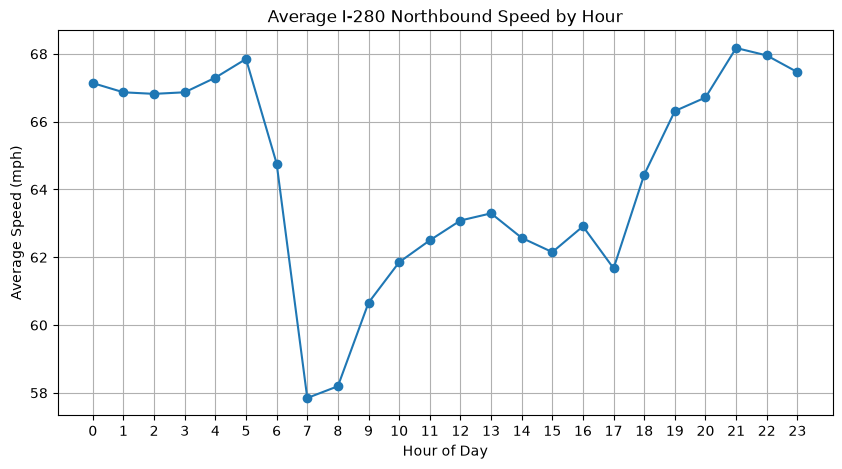

In [57]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_speed.index, hourly_speed.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Speed (mph)")
plt.title("Average I-280 Northbound Speed by Hour")

plt.xticks(range(0, 24))
plt.grid(True)

plt.show()

In [58]:
station_speed = df.groupby("station")["speed"].mean()
station_speed

station
De Anza Blvd     64.471181
Stevens Creek    65.168998
Wolfe Rd         63.537897
Name: speed, dtype: float64

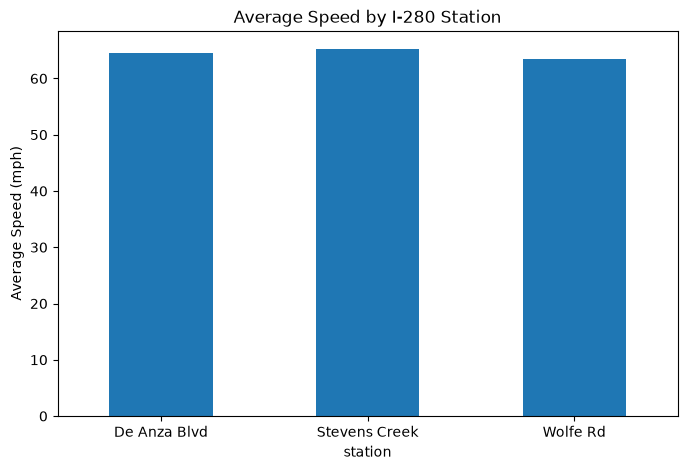

In [59]:
plt.figure(figsize=(8, 5))

station_speed.plot(kind="bar")

plt.ylabel("Average Speed (mph)")
plt.title("Average Speed by I-280 Station")
plt.xticks(rotation=0)

plt.show()

In [60]:
station_hourly = (
    df.groupby(["hour", "station"])["speed"]
      .mean()
      .unstack()
)

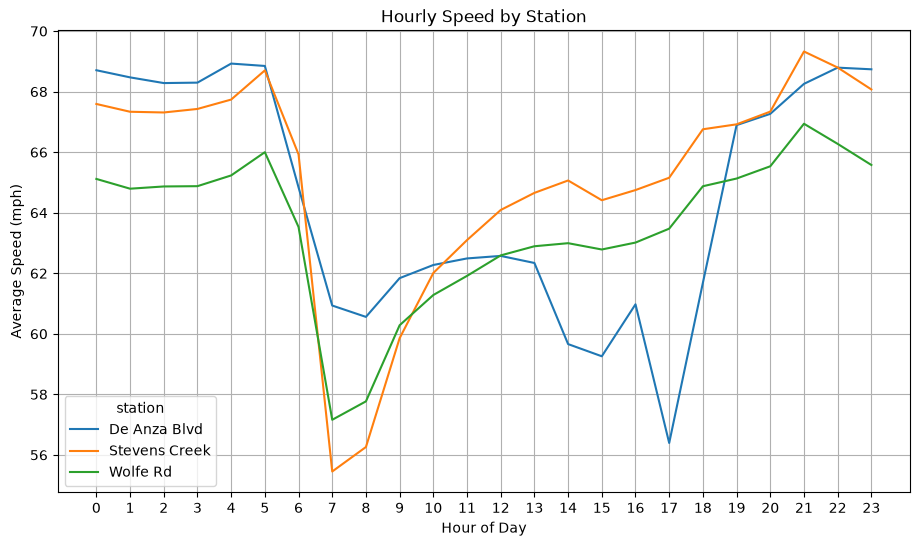

In [61]:
station_hourly.plot(figsize=(11, 6))

plt.xlabel("Hour of Day")
plt.ylabel("Average Speed (mph)")
plt.title("Hourly Speed by Station")
plt.xticks(range(24))
plt.grid(True)

plt.show()

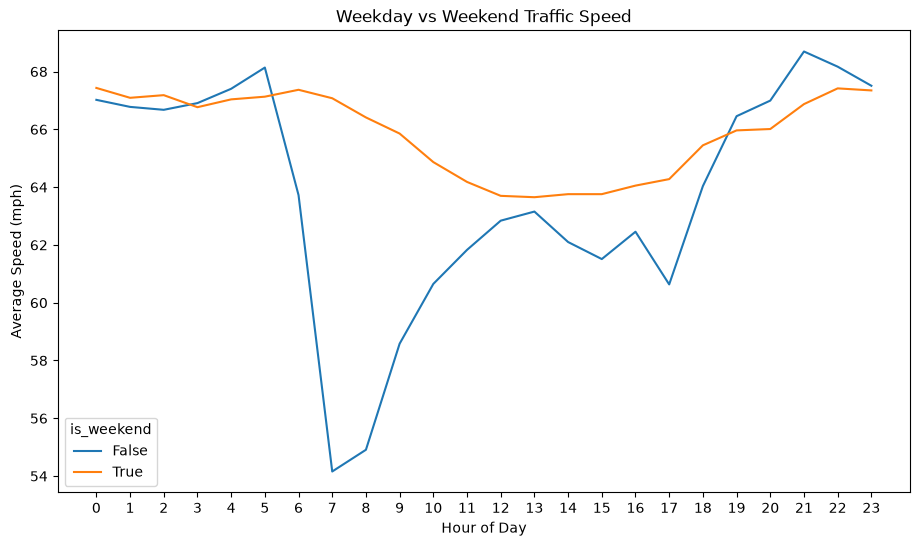

In [62]:
weekday_weekend = (
    df.groupby(["hour", "is_weekend"])["speed"]
      .mean()
      .unstack()
)
weekday_weekend.plot(figsize=(11, 6))

plt.xlabel("Hour of Day")
plt.ylabel("Average Speed (mph)")
plt.title("Weekday vs Weekend Traffic Speed")
plt.xticks(range(24))

plt.show()

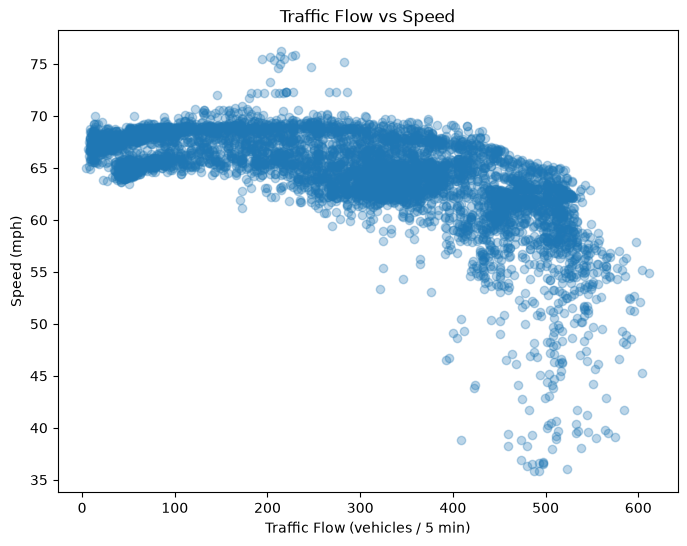

In [63]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["flow"],
    df["speed"],
    alpha=0.3
)

plt.xlabel("Traffic Flow (vehicles / 5 min)")
plt.ylabel("Speed (mph)")
plt.title("Traffic Flow vs Speed")

plt.show()

In [64]:
df[["flow", "speed"]].corr()

,flow,speed
flow,1.000000,-0.615969
speed,-0.615969,1.000000


In [65]:
df.to_csv(
    "../data/processed/i280_nb_cleaned.csv",
    index=False
)

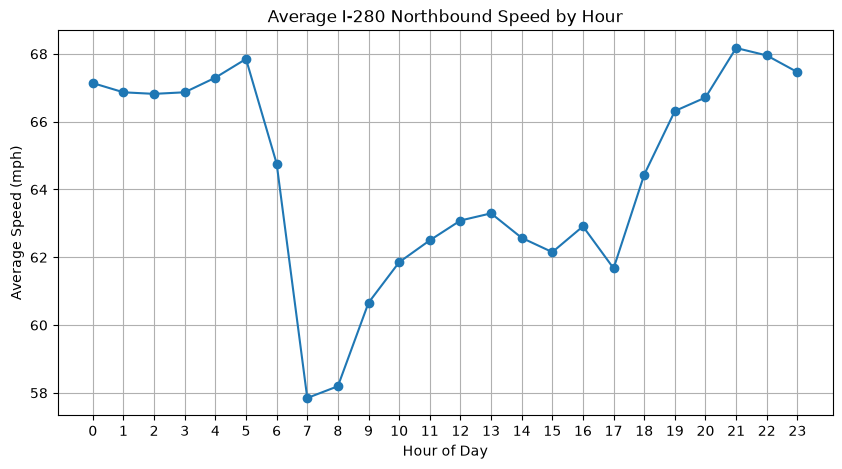

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_speed.index, hourly_speed.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Speed (mph)")
plt.title("Average I-280 Northbound Speed by Hour")
plt.xticks(range(24))
plt.grid(True)

plt.savefig(
    "../images/average_speed_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

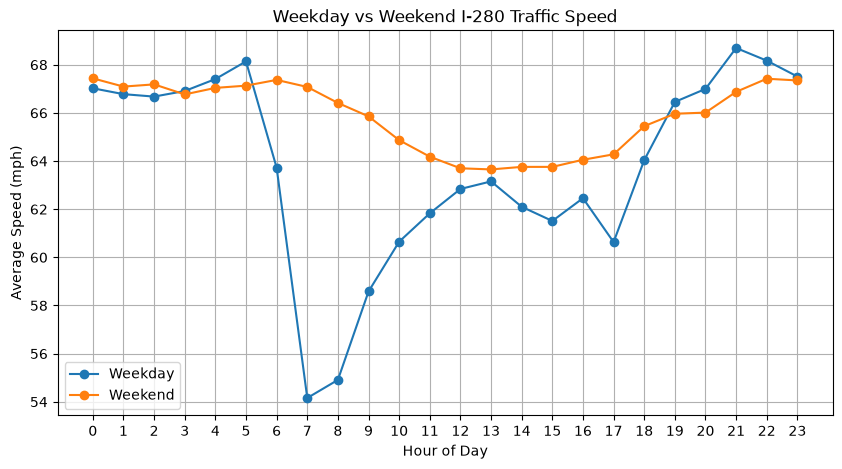

In [67]:
weekday_weekend = (
    df.groupby(["hour", "is_weekend"])["speed"]
      .mean()
      .unstack()
)

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_weekend.index,
    weekday_weekend[False],
    marker="o",
    label="Weekday"
)

plt.plot(
    weekday_weekend.index,
    weekday_weekend[True],
    marker="o",
    label="Weekend"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Speed (mph)")
plt.title("Weekday vs Weekend I-280 Traffic Speed")
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.savefig(
    "../images/weekday_weekend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
station_speed = df.groupby("station")["speed"].mean()

station_speed

station
De Anza Blvd     64.471181
Stevens Creek    65.168998
Wolfe Rd         63.537897
Name: speed, dtype: float64

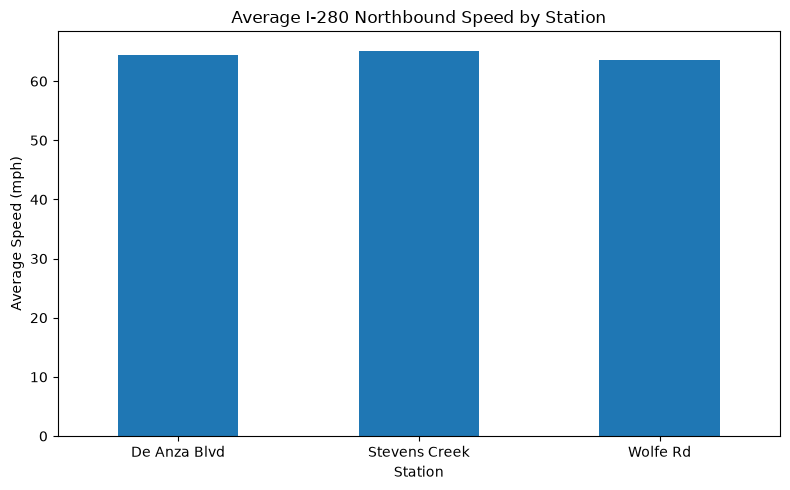

In [69]:
plt.figure(figsize=(8, 5))

station_speed.plot(kind="bar")

plt.xlabel("Station")
plt.ylabel("Average Speed (mph)")
plt.title("Average I-280 Northbound Speed by Station")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../images/station_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()